LaTeX has been enabled for text rendering.
        RELATÓRIO ESTATÍSTICO DO SISTEMA PETC DUAL-CHANNEL        
 Período de Amostragem (h)       : 0.0500 s
 Amostras Discretas (s_m)        : 601
 Transmissões Canal SC (Sensor)  : 423
 Redução de Tráfego Canal SC     : 29.62%
 Transmissões Canal CA (Atuador) : 156
 Redução de Tráfego Canal CA     : 74.04%
--------------------------------------------------------------
 Norma do Erro ||e[s_m]||: RMS = 0.042445 | Máx Abs = 0.441864


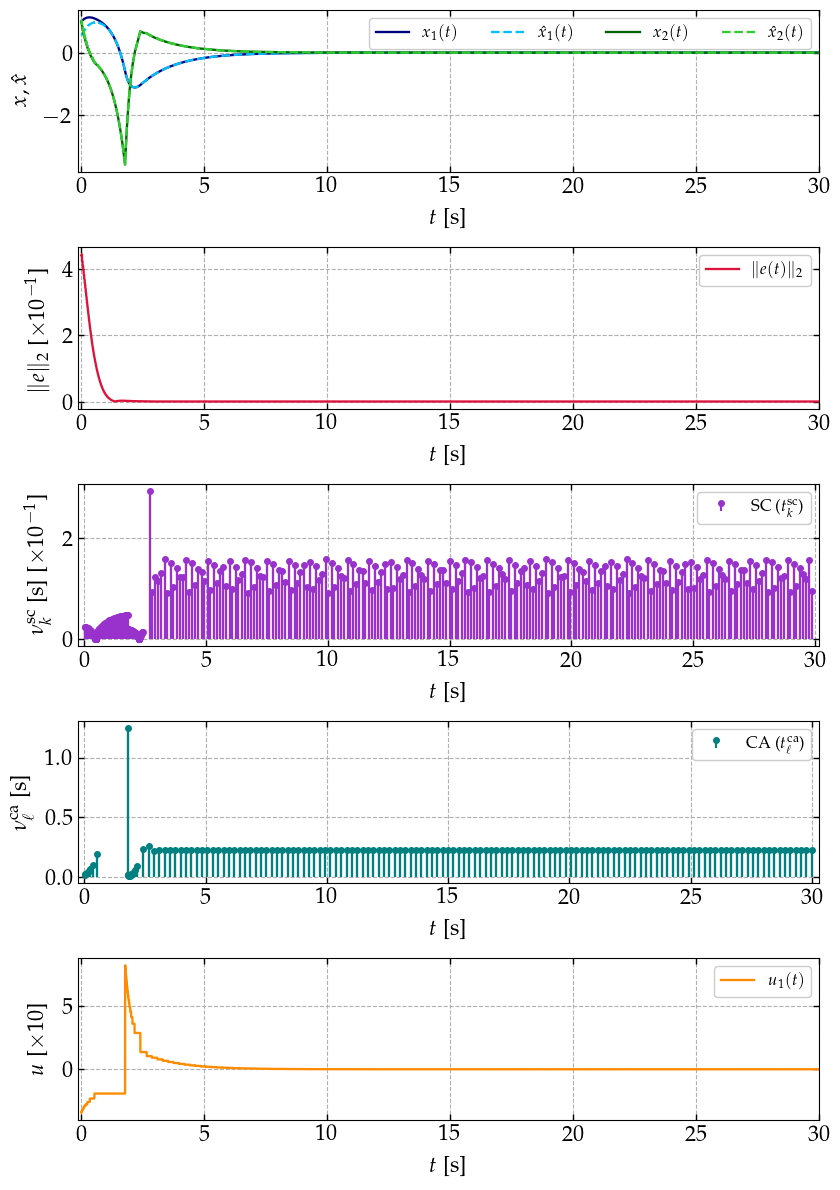

In [12]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from Utils import Graphs, Notebook

Notebook.setup()


def load_signal(filepath: str) -> np.ndarray:
  return np.fromfile(filepath, dtype='float64')


dir_path = 'simulations/lit-system-dual-channel-setm'

# -------------------------------------------------------------
# 1. CARREGAMENTO DOS DADOS DA SIMULAÇÃO DUAL-CHANNEL
# -------------------------------------------------------------
h = 5e-2  # Período de amostragem fundamental

time = load_signal(f'{dir_path}/time.bin')
sc_trigger_times = load_signal(f'{dir_path}/sc_trigger_times.bin')
ca_trigger_times = load_signal(f'{dir_path}/ca_trigger_times.bin')

x1 = load_signal(f'{dir_path}/x1.bin')
x2 = load_signal(f'{dir_path}/x2.bin')
x_est1 = load_signal(f'{dir_path}/x_est1.bin')
x_est2 = load_signal(f'{dir_path}/x_est2.bin')
e1 = load_signal(f'{dir_path}/e1.bin')
e2 = load_signal(f'{dir_path}/e2.bin')
u1 = load_signal(f'{dir_path}/u1.bin')

# -------------------------------------------------------------
# 2. PROCESSAMENTO ESTATÍSTICO E AMOSTRAGEM DISCRETA
# -------------------------------------------------------------
dt = time[1] - time[0]
step_ratio = int(np.round(h / dt))

sample_indices = np.arange(0, len(time), step_ratio)
s_m_times = time[sample_indices]

error_norm = np.sqrt(e1**2 + e2**2)
error_norm_sm = error_norm[sample_indices]

# Tratamento para o canal SC (Sensor-Controlador)
sc_inter_event_times = np.zeros_like(sc_trigger_times)
if len(sc_trigger_times) > 1:
  sc_inter_event_times[1:] = np.diff(sc_trigger_times)
sc_iet_valid = (
    sc_inter_event_times[1:]
    if len(sc_inter_event_times) > 1
    else np.array([0.0])
)
sc_trigger_valid = (
    sc_trigger_times[1:] if len(sc_trigger_times) > 1 else np.array([0.0])
)

sc_iet_mean = float(np.mean(sc_iet_valid))
sc_transmissions = len(sc_trigger_times)

# Tratamento para o canal CA (Controlador-Atuador)
ca_inter_event_times = np.zeros_like(ca_trigger_times)
if len(ca_trigger_times) > 1:
  ca_inter_event_times[1:] = np.diff(ca_trigger_times)
ca_iet_valid = (
    ca_inter_event_times[1:]
    if len(ca_inter_event_times) > 1
    else np.array([0.0])
)
ca_trigger_valid = (
    ca_trigger_times[1:] if len(ca_trigger_times) > 1 else np.array([0.0])
)

ca_iet_mean = float(np.mean(ca_iet_valid))
ca_transmissions = len(ca_trigger_times)

total_samples_sm = len(s_m_times)
sc_reduction_pct = (1.0 - (sc_transmissions / total_samples_sm)) * 100.0
ca_reduction_pct = (1.0 - (ca_transmissions / total_samples_sm)) * 100.0

norm_rms = float(np.sqrt(np.mean(error_norm_sm**2)))
norm_max = float(np.max(np.abs(error_norm_sm)))

plot_style = Graphs.PlotStyle()
plot_style.legend_ncol = 4

print('=' * 62)
print('        RELATÓRIO ESTATÍSTICO DO SISTEMA PETC DUAL-CHANNEL        ')
print('=' * 62)
print(f' Período de Amostragem (h)       : {h:.4f} s')
print(f' Amostras Discretas (s_m)        : {total_samples_sm}')
print(f' Transmissões Canal SC (Sensor)  : {sc_transmissions}')
print(f' Redução de Tráfego Canal SC     : {sc_reduction_pct:.2f}%')
print(f' Transmissões Canal CA (Atuador) : {ca_transmissions}')
print(f' Redução de Tráfego Canal CA     : {ca_reduction_pct:.2f}%')
print('-' * 62)
print(
    f' Norma do Erro ||e[s_m]||: RMS = {norm_rms:.6f} | Máx Abs = {norm_max:.6f}'
)
print('=' * 62)

# -------------------------------------------------------------
# 3. PLOTAGEM VIA UTILITÁRIO GPH (SUBPLOT MOSAIC)
# -------------------------------------------------------------
fig, axs = plt.subplot_mosaic(
    [['x'], ['e'], ['iet_sc'], ['iet_ca'], ['u']], figsize=(8.5, 12)
)

# 1. Estados Reais vs. Estimados
_ = Graphs.plot(
    axs['x'],
    time,
    [x1, x_est1, x2, x_est2],
    label=[r'$x_1(t)$', r'$\hat{x}_1(t)$', r'$x_2(t)$', r'$\hat{x}_2(t)$'],
    xlabel='$t$',
    x_unit='s',
    x_use_prefixes=True,
    ylabel=r'$x, \hat{x}$',
    color=['navy', 'deepskyblue', 'darkgreen', 'limegreen'],
    linestyle=['-', '--', '-', '--'],
    x_pad=(0.005, 0.0),
    y_pad=(0.05, 0.05),
    style=plot_style,
)

# 2. Norma Contínua do Erro de Estimação
_ = Graphs.plot(
    axs['e'],
    time,
    [error_norm],
    label=[r'$\|e(t)\|_2$'],
    xlabel='$t$',
    x_unit='s',
    x_use_prefixes=True,
    ylabel=r'$\|e\|_2$',
    color=['crimson'],
    x_pad=(0.005, 0.0),
    y_pad=(0.05, 0.05),
)

# 3. Intervalos Inter-Eventos - Canal SC (Stem)
_ = Graphs.stem(
    axs['iet_sc'],
    sc_trigger_valid,
    sc_iet_valid,
    label=[r'SC ($t_k^{\mathrm{sc}}$)'],
    xlabel='$t$',
    x_unit='s',
    x_use_prefixes=True,
    ylabel=r'$\nu_k^{\mathrm{sc}}$ [s]',
    color=['darkorchid'],
    x_pad=(0.01, 0.01),
    y_pad=(0.05, 0.05),
)

# 4. Intervalos Inter-Eventos - Canal CA (Stem)
_ = Graphs.stem(
    axs['iet_ca'],
    ca_trigger_valid,
    ca_iet_valid,
    label=[r'CA ($t_\ell^{\mathrm{ca}}$)'],
    xlabel='$t$',
    x_unit='s',
    x_use_prefixes=True,
    ylabel=r'$\nu_\ell^{\mathrm{ca}}$ [s]',
    color=['teal'],
    x_pad=(0.01, 0.01),
    y_pad=(0.05, 0.05),
)

# 5. Sinal de Controle em Malha Fechada (ZOH)
_ = Graphs.plot(
    axs['u'],
    time,
    [u1],
    label=[r'$u_1(t)$'],
    xlabel='$t$',
    x_unit='s',
    x_use_prefixes=True,
    ylabel=r'$u$',
    color=['darkorange'],
    x_pad=(0.005, 0.0),
    y_pad=(0.05, 0.05),
)

plt.tight_layout()
plt.show()

     RELATÓRIO ESTATÍSTICO: PETC COM OBSERVADOR DE LUENBERGER       
 Período de Amostragem Base (h)     : 100.00 ms
 Passo de Integração RK5 (dt)       : 100.0 µs
 Avaliações Periódicas ETM (s_m)    : 76
 Transmissões Efetivas na Rede      : 20
 Redução de Tráfego Global          : 73.68%
--------------------------------------------------------------------
 Intervalo Entre Eventos (IET) Médio: 0.3421 s
 IET Mínimo / Máximo Registrado     : 0.0001 s / 1.2000 s
--------------------------------------------------------------------
 Norma do Erro ||e[s_m]|| - RMS     : 0.433356
 Norma do Erro ||e[s_m]|| - Máx Abs : 2.841593


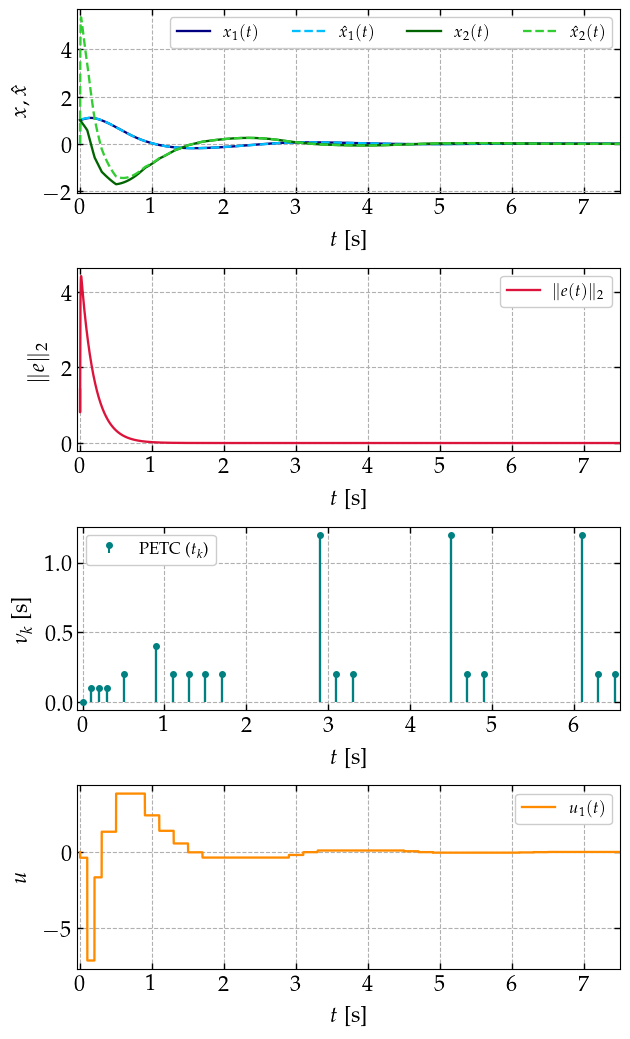

In [13]:
from pathlib import Path

dir_path = Path("simulations/lit-system-observer-petc")
h = 1e-1  # Período de amostragem fundamental do ETM (h = 1 ms)

time = load_signal(dir_path / "time.bin")
ca_trigger_times = load_signal(dir_path / "ca_trigger_times.bin")

x1 = load_signal(dir_path / "x1.bin")
x2 = load_signal(dir_path / "x2.bin")
x_est1 = load_signal(dir_path / "x_est1.bin")
x_est2 = load_signal(dir_path / "x_est2.bin")
e1 = load_signal(dir_path / "e1.bin")
e2 = load_signal(dir_path / "e2.bin")
u1 = load_signal(dir_path / "u1.bin")

dt = float(time[1] - time[0])
step_ratio = int(np.round(h / dt))

# Subamostragem síncrona nos instantes periódicos s_m = m * h
sample_indices = np.arange(0, len(time), step_ratio)
s_m_times = time[sample_indices]

# Norma euclidiana contínua e discreta do erro de estimação e(t) = x(t) - x_hat(t)
error_norm = np.sqrt(e1**2 + e2**2)
error_norm_sm = error_norm[sample_indices]

# Métricas do canal PETC (Transmissão de x_hat para o Controlador/Atuador)
ca_inter_event_times = np.zeros_like(ca_trigger_times)
if len(ca_trigger_times) > 1:
  ca_inter_event_times[1:] = np.diff(ca_trigger_times)

ca_iet_valid = (
    ca_inter_event_times[1:] if len(ca_trigger_times) > 1 else np.array([0.0])
)
ca_trigger_valid = (
    ca_trigger_times[1:] if len(ca_trigger_times) > 1 else np.array([0.0])
)

ca_iet_mean = float(np.mean(ca_iet_valid))
ca_iet_min = float(np.min(ca_iet_valid))
ca_iet_max = float(np.max(ca_iet_valid))
ca_transmissions = len(ca_trigger_times)

total_samples_sm = len(s_m_times)
network_reduction_pct = (1.0 - (ca_transmissions / total_samples_sm)) * 100.0

norm_rms = float(np.sqrt(np.mean(error_norm_sm**2)))
norm_max = float(np.max(np.abs(error_norm_sm)))

print("=" * 68)
print("     RELATÓRIO ESTATÍSTICO: PETC COM OBSERVADOR DE LUENBERGER       ")
print("=" * 68)
print(f" Período de Amostragem Base (h)     : {h * 1e3:.2f} ms")
print(f" Passo de Integração RK5 (dt)       : {dt * 1e6:.1f} µs")
print(f" Avaliações Periódicas ETM (s_m)    : {total_samples_sm}")
print(f" Transmissões Efetivas na Rede      : {ca_transmissions}")
print(f" Redução de Tráfego Global          : {network_reduction_pct:.2f}%")
print("-" * 68)
print(f" Intervalo Entre Eventos (IET) Médio: {ca_iet_mean:.4f} s")
print(
    f" IET Mínimo / Máximo Registrado     : {ca_iet_min:.4f} s / {ca_iet_max:.4f} s")
print("-" * 68)
print(f" Norma do Erro ||e[s_m]|| - RMS     : {norm_rms:.6f}")
print(f" Norma do Erro ||e[s_m]|| - Máx Abs : {norm_max:.6f}")
print("=" * 68)

plot_style = Graphs.PlotStyle()
plot_style.legend_ncol = 4

# Como o observador é co-alocado ao sensor (canal SC contínuo),
# exibe-se apenas a malha PETC de transmissão de estados estimados
fig, axs = plt.subplot_mosaic(
    [["x"], ["e"], ["iet"], ["u"]], figsize=(6.4, 10.5)
)

# 1. Estados Reais da Planta vs. Estados Estimados pelo Observador
_ = Graphs.plot(
    axs["x"],
    time,
    [x1, x_est1, x2, x_est2],
    label=[r"$x_1(t)$", r"$\hat{x}_1(t)$", r"$x_2(t)$", r"$\hat{x}_2(t)$"],
    xlabel="$t$",
    x_unit="s",
    x_use_prefixes=True,
    ylabel=r"$x, \hat{x}$",
    color=["navy", "deepskyblue", "darkgreen", "limegreen"],
    linestyle=["-", "--", "-", "--"],
    x_pad=(0.005, 0.0),
    y_pad=(0.05, 0.05),
    style=plot_style,
)

# 2. Norma Euclidiana Contínua do Erro de Estimação ||e(t)||_2
_ = Graphs.plot(
    axs["e"],
    time,
    [error_norm],
    label=[r"$\|e(t)\|_2$"],
    xlabel="$t$",
    x_unit="s",
    x_use_prefixes=True,
    ylabel=r"$\|e\|_2$",
    color=["crimson"],
    x_pad=(0.005, 0.0),
    y_pad=(0.05, 0.05),
)

# 3. Intervalos Inter-Eventos da Rede (IETs) - Canal PETC
_ = Graphs.stem(
    axs["iet"],
    ca_trigger_valid,
    ca_iet_valid,
    label=[r"PETC ($t_k$)"],
    xlabel="$t$",
    x_unit="s",
    x_use_prefixes=True,
    ylabel=r"$\nu_k$ [s]",
    color=["teal"],
    x_pad=(0.01, 0.01),
    y_pad=(0.05, 0.05),
)

# 4. Esforço de Controle Sustentado pelo ZOH
_ = Graphs.plot(
    axs["u"],
    time,
    [u1],
    label=[r"$u_1(t)$"],
    xlabel="$t$",
    x_unit="s",
    x_use_prefixes=True,
    ylabel=r"$u$",
    color=["darkorange"],
    x_pad=(0.005, 0.0),
    y_pad=(0.05, 0.05),
)

plt.tight_layout()
plt.show()

LaTeX has been enabled for text rendering.
     RELATÓRIO DIAGNÓSTICO: PETC SOB ATAQUES FDI E MITIGAÇÃO            
 Duração Total da Simulação (T)       : 7.5000 s
 Período Base de Amostragem (h)       : 100.00 ms
 Limiar de Detecção (J_th)            : 0.2000
 Duração Total do Ataque Injetado     : 2.9999 s
------------------------------------------------------------------------
 Falsos Positivos (FP - Alarme falso) : 1 evento(s) | 0.0053 s
 Falsos Negativos (FN - Ataque oculto): 1 evento(s) | 2.9999 s
 Transmissões CA Corrompidas por FN   : 6 pacote(s)
 Taxa de Exposição da Malha ao FDI    : 100.00%


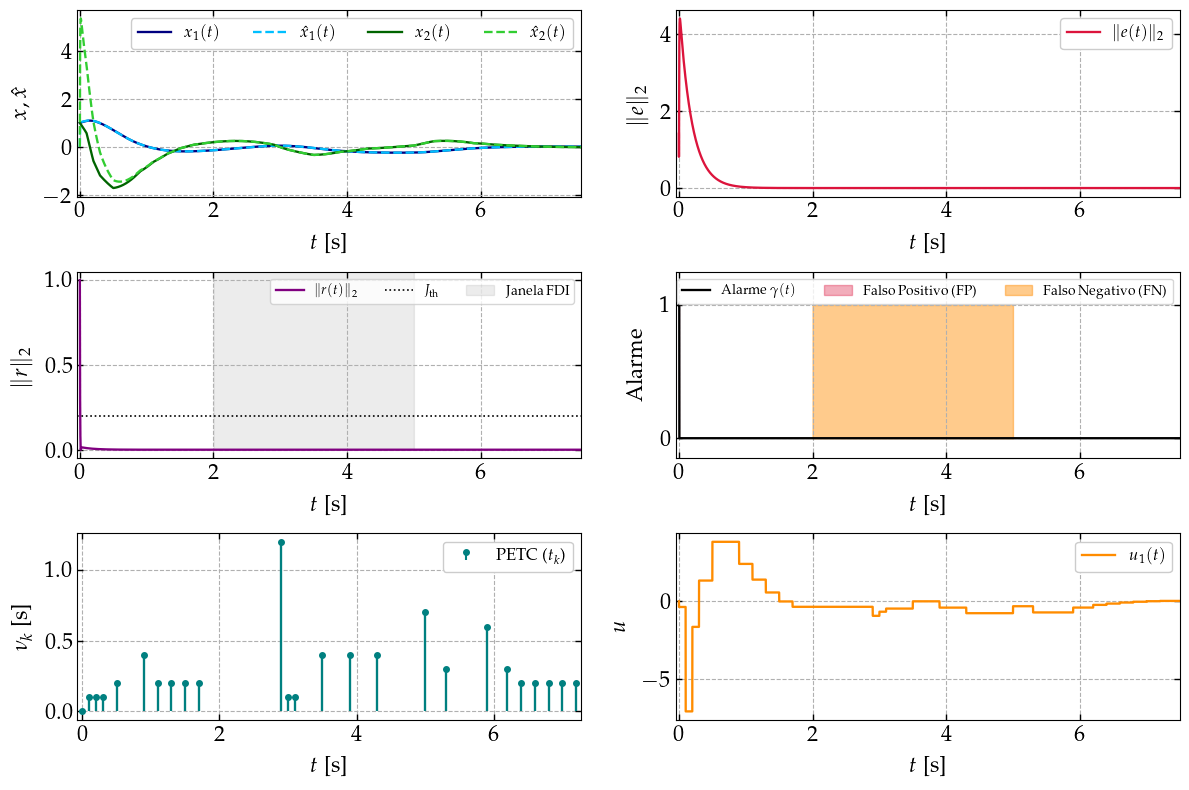

In [14]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from Utils import Graphs, Notebook

Notebook.setup()


def load_signal(filepath: Path | str) -> np.ndarray:
  """Carrega vetores binários float64 exportados pelo BinaryLogger."""
  return np.fromfile(filepath, dtype=np.float64)


# -------------------------------------------------------------------------
# 1. CONFIGURAÇÃO DE PARÂMETROS E CARREGAMENTO DE DADOS
# -------------------------------------------------------------------------
dir_path = Path("simulations/lit-system-under-attack")
h = 1e-1  # Período fundamental de amostragem do ETM (h = 100 ms)
detection_threshold = 0.2  # Limiar analítico do resíduo ||r(t)||_2

time = load_signal(dir_path / "time.bin")
ca_trigger_times = load_signal(dir_path / "ca_trigger_times.bin")
residual_norm = load_signal(dir_path / "residual_norm.bin")

x1 = load_signal(dir_path / "x1.bin")
x2 = load_signal(dir_path / "x2.bin")
x_est1 = load_signal(dir_path / "x_est1.bin")
x_est2 = load_signal(dir_path / "x_est2.bin")
e1 = load_signal(dir_path / "e1.bin")
e2 = load_signal(dir_path / "e2.bin")
u1 = load_signal(dir_path / "u1.bin")

# Carrega r1 e alarm_active caso persistidos em disco; senão infere do resíduo
r1_path = dir_path / "r1.bin"
r1 = load_signal(r1_path) if r1_path.exists() else None

alarm_path = dir_path / "alarm_active.bin"
if alarm_path.exists():
  alarm_active = load_signal(alarm_path) > 0.5
else:
  alarm_active = residual_norm > detection_threshold

dt = float(time[1] - time[0])
duration = float(time[-1])
num_steps = len(time)
step_ratio = int(np.round(h / dt))

# -------------------------------------------------------------------------
# 2. DEFINIÇÃO DIRETA DO SINAL DE ATAQUE FDI (GROUND TRUTH)
# -------------------------------------------------------------------------
a1_path = dir_path / "a1.bin"
if a1_path.exists():
  attack_signal = load_signal(a1_path)
  attack_present = np.abs(attack_signal) > 1e-9
else:
  def fdi_attack(t: np.ndarray) -> np.ndarray:
    return np.where((t >= 2.0) & (t <= 5.0), 0.5, 0.0)

  attack_signal = fdi_attack(time)
  attack_present = np.abs(attack_signal) > 1e-9

# -------------------------------------------------------------------------
# 3. DIAGNÓSTICO DE SEGURANÇA: FALSOS POSITIVOS E FALSOS NEGATIVOS
# -------------------------------------------------------------------------
# Métrica 1: Falsos Positivos (Alarme ativo sem ataque presente: H0 violada)
false_alarm_mask = alarm_active & (~attack_present)
false_positive_events = int(
    np.sum(np.diff(false_alarm_mask.astype(int)) == 1)
) + (1 if false_alarm_mask[0] else 0)
total_false_alarm_duration = float(np.sum(false_alarm_mask) * dt)

# Métrica 2: Falsos Negativos (Ataque ativo sem disparo: Falha do detector / Controle exposto)
false_negative_mask = attack_present & (~alarm_active)
false_negative_events = int(
    np.sum(np.diff(false_negative_mask.astype(int)) == 1)
) + (1 if false_negative_mask[0] else 0)
total_malicious_duration = float(np.sum(false_negative_mask) * dt)
malicious_control_steps = int(np.sum(false_negative_mask))

# Mapeia transmissões CA afetadas por falsos negativos
trigger_indices = np.clip(np.searchsorted(
    time, ca_trigger_times), 0, num_steps - 1)
malicious_control_transmissions = int(
    np.sum(false_negative_mask[trigger_indices]))

# Atraso de detecção no primeiro ataque
attack_start_idx = np.where(attack_present)[0]
detection_delay = -1.0
if len(attack_start_idx) > 0:
  t_start = time[attack_start_idx[0]]
  first_detect_idx = np.where(attack_present & alarm_active)[0]
  if len(first_detect_idx) > 0:
    detection_delay = float(time[first_detect_idx[0]] - t_start)

# -------------------------------------------------------------------------
# 4. MÉTRICAS DE REDE E DESEMPENHO DINÂMICO
# -------------------------------------------------------------------------
sample_indices = np.arange(0, num_steps, step_ratio)
s_m_times = time[sample_indices]
total_samples_sm = len(s_m_times)
ca_transmissions = len(ca_trigger_times)
network_reduction_pct = (1.0 - (ca_transmissions / total_samples_sm)) * 100.0

ca_iet_valid = np.diff(
    ca_trigger_times) if ca_transmissions > 1 else np.array([0.0])
ca_trigger_valid = ca_trigger_times[1:] if ca_transmissions > 1 else np.array([
                                                                              0.0])
ca_iet_mean = float(np.mean(ca_iet_valid))
ca_iet_min = float(np.min(ca_iet_valid))
ca_iet_max = float(np.max(ca_iet_valid))

error_norm = np.sqrt(e1**2 + e2**2)
err_norm_rms = float(np.sqrt(np.mean(error_norm**2)))
err_norm_max = float(np.max(error_norm))

res_norm_rms = float(np.sqrt(np.mean(residual_norm**2)))
res_norm_max = float(np.max(residual_norm))

total_attack_duration = float(np.sum(attack_present) * dt)
malicious_exposure_pct = (
    (total_malicious_duration / total_attack_duration) * 100.0
    if total_attack_duration > 0
    else 0.0
)

# -------------------------------------------------------------------------
# 5. RELATÓRIO ESTATÍSTICO NO TERMINAL
# -------------------------------------------------------------------------
print("=" * 72)
print("     RELATÓRIO DIAGNÓSTICO: PETC SOB ATAQUES FDI E MITIGAÇÃO            ")
print("=" * 72)
print(f" Duração Total da Simulação (T)       : {duration:.4f} s")
print(f" Período Base de Amostragem (h)       : {h * 1e3:.2f} ms")
print(f" Limiar de Detecção (J_th)            : {detection_threshold:.4f}")
print(f" Duração Total do Ataque Injetado     : {total_attack_duration:.4f} s")
print("-" * 72)
print(
    f" Falsos Positivos (FP - Alarme falso) : {false_positive_events} evento(s) | {total_false_alarm_duration:.4f} s")
print(
    f" Falsos Negativos (FN - Ataque oculto): {false_negative_events} evento(s) | {total_malicious_duration:.4f} s")
print(
    f" Transmissões CA Corrompidas por FN   : {malicious_control_transmissions} pacote(s)")
print(f" Taxa de Exposição da Malha ao FDI    : {malicious_exposure_pct:.2f}%")
if detection_delay >= 0:
  print(
      f" Atraso de Detecção no Início do FDI  : {detection_delay * 1e3:.2f} ms")
print("=" * 72)

# -------------------------------------------------------------------------
# 6. VISUALIZAÇÃO GRÁFICA: MOSAICO COM SUBPLOT DE ALARME (FP & FN)
# -------------------------------------------------------------------------
plot_style = Graphs.PlotStyle()
plot_style.legend_ncol = 4

# Mosaico de 6 eixos verticais
fig, axs = plt.subplot_mosaic(
    [["x", "e"], ["residual", "alarm"], ["iet", "u"]],
    figsize=(12, 8),
)

# (a) Estados Reais vs. Estimados
_ = Graphs.plot(
    axs["x"],
    time,
    [x1, x_est1, x2, x_est2],
    label=[r"$x_1(t)$", r"$\hat{x}_1(t)$", r"$x_2(t)$", r"$\hat{x}_2(t)$"],
    xlabel="$t$",
    x_unit="s",
    x_use_prefixes=True,
    ylabel=r"$x, \hat{x}$",
    color=["navy", "deepskyblue", "darkgreen", "limegreen"],
    linestyle=["-", "--", "-", "--"],
    x_pad=(0.005, 0.0),
    y_pad=(0.05, 0.05),
    style=plot_style,
)

# (b) Norma Euclidiana do Erro de Estimação ||e(t)||_2
_ = Graphs.plot(
    axs["e"],
    time,
    [error_norm],
    label=[r"$\|e(t)\|_2$"],
    xlabel="$t$",
    x_unit="s",
    x_use_prefixes=True,
    ylabel=r"$\|e\|_2$",
    color=["crimson"],
    x_pad=(0.005, 0.0),
    y_pad=(0.05, 0.05),
)

# (c) Resíduo de Saída ||r(t)||_2 e Limiar
_ = Graphs.plot(
    axs["residual"],
    time,
    [residual_norm],
    label=[r"$\|r(t)\|_2$"],
    xlabel="$t$",
    x_unit="s",
    x_use_prefixes=True,
    ylabel=r"$\|r\|_2$",
    color=["purple"],
    x_pad=(0.005, 0.0),
    y_pad=(0.05, 0.05),
)
axs["residual"].axhline(
    detection_threshold, color="black", linestyle=":", linewidth=1.2, label=r"$J_{\mathrm{th}}$"
)
axs["residual"].fill_between(
    time, 0, np.max(residual_norm) * 1.05, where=attack_present,
    color="gray", alpha=0.15, label="Janela FDI"
)
axs["residual"].legend(loc="upper right", ncol=3)

# (d) Sinal do Alarme com Destaque para Falsos Positivos e Falsos Negativos
alarm_signal_float = alarm_active.astype(float)
_ = Graphs.plot(
    axs["alarm"],
    time,
    [alarm_signal_float],
    label=[r"Alarme $\gamma(t)$"],
    xlabel="$t$",
    x_unit="s",
    x_use_prefixes=True,
    ylabel=r"Alarme",
    color=["black"],
    linestyle=["-"],
    x_pad=(0.005, 0.0),
    y_pad=(0.05, 0.05),
)

# Regiões de inconsistência diagnóstica
axs["alarm"].fill_between(
    time, 0, 1.0, where=false_alarm_mask,
    color="crimson", alpha=0.35, step="mid", label="Falso Positivo (FP)"
)
axs["alarm"].fill_between(
    time, 0, 1.0, where=false_negative_mask,
    color="darkorange", alpha=0.45, step="mid", label="Falso Negativo (FN)"
)

axs["alarm"].set_ylim(-0.15, 1.25)
axs["alarm"].set_yticks([0.0, 1.0])
# axs["alarm"].set_yticklabels(["0 (Nominal)", "1 (Alarme)"])
axs["alarm"].legend(loc="upper right", ncol=3)

# (e) Intervalos Inter-Eventos (Canal PETC CA)
_ = Graphs.stem(
    axs["iet"],
    ca_trigger_valid,
    ca_iet_valid,
    label=[r"PETC ($t_k$)"],
    xlabel="$t$",
    x_unit="s",
    x_use_prefixes=True,
    ylabel=r"$\nu_k$ [s]",
    color=["teal"],
    x_pad=(0.01, 0.01),
    y_pad=(0.05, 0.05),
)

# (f) Sinal de Controle em Malha Fechada
_ = Graphs.plot(
    axs["u"],
    time,
    [u1],
    label=[r"$u_1(t)$"],
    xlabel="$t$",
    x_unit="s",
    x_use_prefixes=True,
    ylabel=r"$u$",
    color=["darkorange"],
    x_pad=(0.005, 0.0),
    y_pad=(0.05, 0.05),
)

plt.tight_layout()
plt.show()

LaTeX has been enabled for text rendering.
     RELATÓRIO: DUAL-CHANNEL PETC SOB ATAQUES FDI E MITIGAÇÃO            
 Duração Total da Simulação (T)       : 10.0000 s
 Período Base de Amostragem (h)       : 1.00 ms
 Passo de Integração RK5 (dt)         : 100.0 µs
 Limiar de Detecção Adotado (J_th)    : 0.0010
------------------------------------------------------------------------
 Amostras Periódicas Discretas (s_m)  : 10001
 Transmissões Canal SC (Sensor)       : 31 (Redução: 99.69%)
 IET Médio / Mín / Máx Canal SC       : 0.3233 s / 0.1000 s / 0.5000 s
 Transmissões Canal CA (Atuador)      : 49 (Redução: 99.51%)
 IET Médio / Mín / Máx Canal CA       : 0.2083 s / 0.1000 s / 0.9000 s
------------------------------------------------------------------------
 Norma do Erro ||e[s_m]|| - RMS       : 0.495076
 Norma do Erro ||e[s_m]|| - Máx Abs   : 1.841688
 Resíduo ||r(t_k^sc)|| - RMS          : 0.239362
 Resíduo ||r(t_k^sc)|| - Máximo       : 1.000000
-------------------------------------

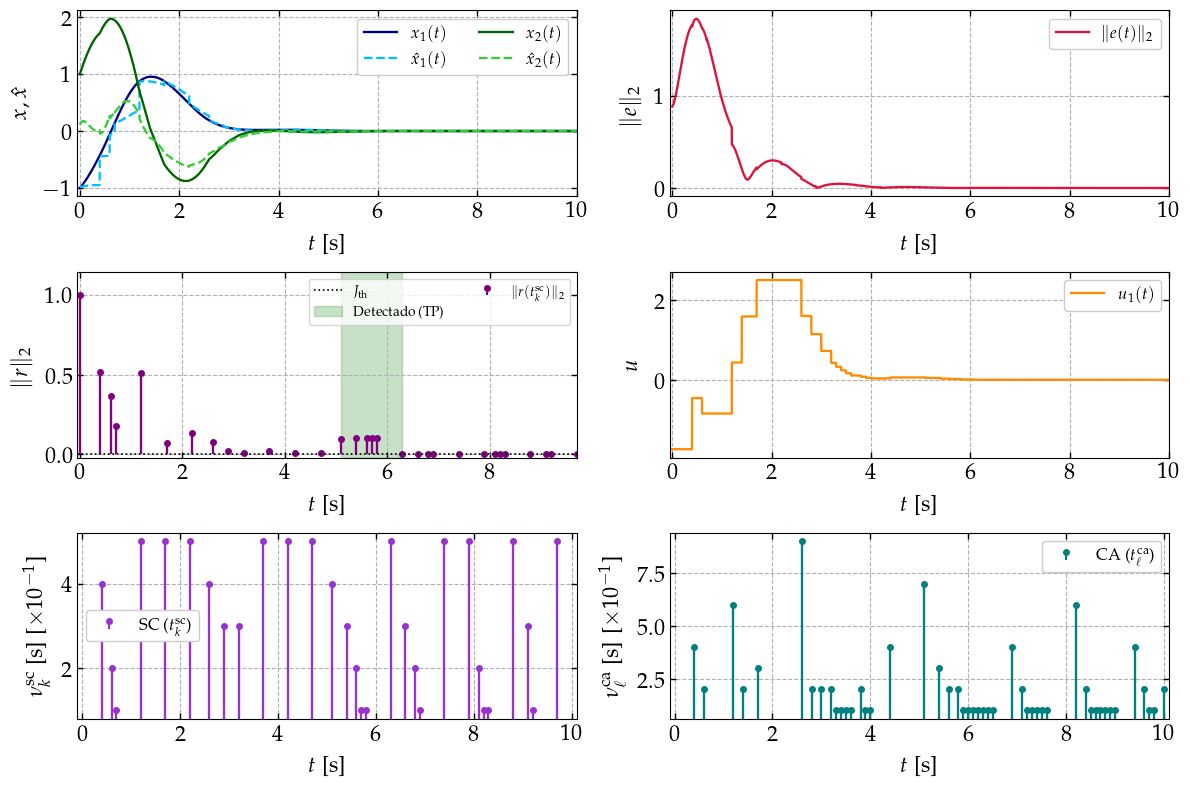

In [3]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from Utils import Graphs, Notebook

Notebook.setup()


def load_signal(filepath: Path | str) -> np.ndarray:
  return np.fromfile(filepath, dtype=np.float64)


dir_path = Path("simulations/lit-system-dual-channel-under-attack")
h = 1e-3
detection_threshold = 1e-3

time = load_signal(dir_path / "time.bin")
sc_trigger_times = load_signal(dir_path / "sc_trigger_times.bin")
ca_trigger_times = load_signal(dir_path / "ca_trigger_times.bin")
residual_norm = load_signal(dir_path / "residual_norm.bin")

x1 = load_signal(dir_path / "x1.bin")
x2 = load_signal(dir_path / "x2.bin")
x_est1 = load_signal(dir_path / "x_est1.bin")
x_est2 = load_signal(dir_path / "x_est2.bin")
e1 = load_signal(dir_path / "e1.bin")
e2 = load_signal(dir_path / "e2.bin")
u1 = load_signal(dir_path / "u1.bin")

alarm_path = dir_path / "alarm_active.bin"
alarm_sc = (
    load_signal(alarm_path) > 0.5
    if alarm_path.exists()
    else np.zeros(len(sc_trigger_times), dtype=bool)
)

atk_path = dir_path / "malicious_attack1.bin"
if atk_path.exists():
  atk_sc = load_signal(atk_path)
  attack_at_sc = np.abs(atk_sc) > 1e-9
else:
  atk_sc = np.where((sc_trigger_times >= 5.0) & (
      sc_trigger_times <= 15.0), 0.5, 0.0)
  attack_at_sc = np.abs(atk_sc) > 1e-9

tp_mask = attack_at_sc & alarm_sc
fn_mask = attack_at_sc & (~alarm_sc)
fp_mask = (~attack_at_sc) & alarm_sc

dt = float(time[1] - time[0])
duration = float(time[-1])
num_steps = len(time)
step_ratio = int(np.round(h / dt))

sample_indices = np.arange(0, num_steps, step_ratio)
s_m_times = time[sample_indices]
total_samples_sm = len(s_m_times)

error_norm = np.sqrt(e1**2 + e2**2)
error_norm_sm = error_norm[sample_indices]

sc_indices = np.clip(np.searchsorted(
    time, sc_trigger_times), 0, len(residual_norm) - 1)
residual_sc = residual_norm[sc_indices]

sc_iet_valid = np.diff(sc_trigger_times) if len(
    sc_trigger_times) > 1 else np.array([0.0])
sc_trigger_valid = sc_trigger_times[1:] if len(
    sc_trigger_times) > 1 else np.array([0.0])
sc_iet_mean = float(np.mean(sc_iet_valid))
sc_iet_min = float(np.min(sc_iet_valid))
sc_iet_max = float(np.max(sc_iet_valid))
sc_transmissions = len(sc_trigger_times)
sc_reduction_pct = (1.0 - (sc_transmissions / total_samples_sm)) * 100.0

ca_iet_valid = np.diff(ca_trigger_times) if len(
    ca_trigger_times) > 1 else np.array([0.0])
ca_trigger_valid = ca_trigger_times[1:] if len(
    ca_trigger_times) > 1 else np.array([0.0])
ca_iet_mean = float(np.mean(ca_iet_valid))
ca_iet_min = float(np.min(ca_iet_valid))
ca_iet_max = float(np.max(ca_iet_valid))
ca_transmissions = len(ca_trigger_times)
ca_reduction_pct = (1.0 - (ca_transmissions / total_samples_sm)) * 100.0

norm_rms = float(np.sqrt(np.mean(error_norm_sm**2)))
norm_max = float(np.max(np.abs(error_norm_sm)))
res_norm_rms = float(np.sqrt(np.mean(residual_sc**2)))
res_norm_max = float(np.max(residual_sc))

tp_count = int(np.sum(tp_mask))
fp_count = int(np.sum(fp_mask))
fn_count = int(np.sum(fn_mask))
total_attacks_sc = int(np.sum(attack_at_sc))

print("=" * 72)
print("     RELATÓRIO: DUAL-CHANNEL PETC SOB ATAQUES FDI E MITIGAÇÃO            ")
print("=" * 72)
print(f" Duração Total da Simulação (T)       : {duration:.4f} s")
print(f" Período Base de Amostragem (h)       : {h * 1e3:.2f} ms")
print(f" Passo de Integração RK5 (dt)         : {dt * 1e6:.1f} µs")
print(f" Limiar de Detecção Adotado (J_th)    : {detection_threshold:.4f}")
print("-" * 72)
print(f" Amostras Periódicas Discretas (s_m)  : {total_samples_sm}")
print(
    f" Transmissões Canal SC (Sensor)       : {sc_transmissions} (Redução: {sc_reduction_pct:.2f}%)")
print(
    f" IET Médio / Mín / Máx Canal SC       : {sc_iet_mean:.4f} s / {sc_iet_min:.4f} s / {sc_iet_max:.4f} s")
print(
    f" Transmissões Canal CA (Atuador)      : {ca_transmissions} (Redução: {ca_reduction_pct:.2f}%)")
print(
    f" IET Médio / Mín / Máx Canal CA       : {ca_iet_mean:.4f} s / {ca_iet_min:.4f} s / {ca_iet_max:.4f} s")
print("-" * 72)
print(f" Norma do Erro ||e[s_m]|| - RMS       : {norm_rms:.6f}")
print(f" Norma do Erro ||e[s_m]|| - Máx Abs   : {norm_max:.6f}")
print(f" Resíduo ||r(t_k^sc)|| - RMS          : {res_norm_rms:.6f}")
print(f" Resíduo ||r(t_k^sc)|| - Máximo       : {res_norm_max:.6f}")
print("-" * 72)
print(f" Total de Disparos SC sob Ataque      : {total_attacks_sc} evento(s)")
print(f" Verdadeiros Positivos (Detectados)   : {tp_count} evento(s)")
print(f" Falsos Positivos (Alarme s/ ataque)  : {fp_count} evento(s)")
print(f" Falsos Negativos (Ataque não mitig.) : {fn_count} evento(s)")
print("=" * 72)

plot_style = Graphs.PlotStyle()
plot_style.legend_ncol = 2

fig, axs = plt.subplot_mosaic(
    [["x", "e"], ["residual", "u"], ["iet_sc", "iet_ca"]],
    figsize=(12, 8),
)

_ = Graphs.plot(
    axs["x"],
    time,
    [x1, x_est1, x2, x_est2],
    label=[r"$x_1(t)$", r"$\hat{x}_1(t)$", r"$x_2(t)$", r"$\hat{x}_2(t)$"],
    xlabel="$t$",
    x_unit="s",
    x_use_prefixes=True,
    ylabel=r"$x, \hat{x}$",
    color=["navy", "deepskyblue", "darkgreen", "limegreen"],
    linestyle=["-", "--", "-", "--"],
    x_pad=(0.005, 0.0),
    y_pad=(0.05, 0.05),
    style=plot_style,
)

_ = Graphs.plot(
    axs["e"],
    time,
    [error_norm],
    label=[r"$\|e(t)\|_2$"],
    xlabel="$t$",
    x_unit="s",
    x_use_prefixes=True,
    ylabel=r"$\|e\|_2$",
    color=["crimson"],
    x_pad=(0.005, 0.0),
    y_pad=(0.05, 0.05),
)

_ = Graphs.stem(
    axs["residual"],
    sc_trigger_times,
    residual_sc,
    label=[r"$\|r(t_k^{\mathrm{sc}})\|_2$"],
    xlabel="$t$",
    x_unit="s",
    x_use_prefixes=True,
    ylabel=r"$\|r\|_2$",
    color=["purple"],
    x_pad=(0.005, 0.0),
    y_pad=(0.05, 0.05),
)
axs["residual"].axhline(
    detection_threshold,
    color="black",
    linestyle=":",
    linewidth=1.2,
    label=r"$J_{\mathrm{th}}$",
)

n_triggers = len(sc_trigger_times)
if n_triggers > 0:
  def get_state(idx: int) -> int:
    if tp_mask[idx]:
      return 1
    if fp_mask[idx]:
      return 2
    if fn_mask[idx]:
      return 3
    return 0

  intervals = []
  curr_state = get_state(0)
  curr_start = sc_trigger_times[0]

  for k in range(1, n_triggers):
    st = get_state(k)
    if st != curr_state:
      intervals.append((curr_state, curr_start, sc_trigger_times[k]))
      curr_state = st
      curr_start = sc_trigger_times[k]
  intervals.append((curr_state, curr_start, duration))

  tp_labeled = False
  fp_labeled = False
  fn_labeled = False

  for st, t_start, t_end in intervals:
    if st == 1:
      lbl = "Detectado (TP)" if not tp_labeled else None
      axs["residual"].axvspan(
          t_start, t_end, color="forestgreen", alpha=0.25, label=lbl)
      tp_labeled = True
    elif st == 2:
      lbl = "Falso Positivo (FP)" if not fp_labeled else None
      axs["residual"].axvspan(
          t_start, t_end, color="crimson", alpha=0.25, label=lbl)
      fp_labeled = True
    elif st == 3:
      lbl = "Não Detectado (FN)" if not fn_labeled else None
      axs["residual"].axvspan(
          t_start, t_end, color="darkorange", alpha=0.35, label=lbl)
      fn_labeled = True

y_max_res = max(float(np.max(residual_sc)), detection_threshold) * 1.15
axs["residual"].set_ylim(-0.02 * y_max_res, y_max_res)
axs["residual"].legend(loc="upper right", ncol=2)

_ = Graphs.plot(
    axs["u"],
    time,
    [u1],
    label=[r"$u_1(t)$"],
    xlabel="$t$",
    x_unit="s",
    x_use_prefixes=True,
    ylabel=r"$u$",
    color=["darkorange"],
    x_pad=(0.005, 0.0),
    y_pad=(0.05, 0.05),
)

_ = Graphs.stem(
    axs["iet_sc"],
    sc_trigger_valid,
    sc_iet_valid,
    label=[r"SC ($t_k^{\mathrm{sc}}$)"],
    xlabel="$t$",
    x_unit="s",
    x_use_prefixes=True,
    ylabel=r"$\nu_k^{\mathrm{sc}}$ [s]",
    color=["darkorchid"],
    x_pad=(0.01, 0.01),
    y_pad=(0.05, 0.05),
    x_range=[time[0], time[-1]]
)

_ = Graphs.stem(
    axs["iet_ca"],
    ca_trigger_valid,
    ca_iet_valid,
    label=[r"CA ($t_\ell^{\mathrm{ca}}$)"],
    xlabel="$t$",
    x_unit="s",
    x_use_prefixes=True,
    ylabel=r"$\nu_\ell^{\mathrm{ca}}$ [s]",
    color=["teal"],
    x_pad=(0.01, 0.01),
    y_pad=(0.05, 0.05),
    x_range=[time[0], time[-1]]
)

plt.tight_layout()
plt.show()